# Setup and Imports

In [1]:
# Core
import importlib
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.legend_handler import HandlerBase
import torch
import h5py
import lazy5
from lazy5.inspect import get_datasets, get_attrs_dset
from datetime import datetime
import matplotlib.patches as patches
import time

# Local modules
import dataset_utils
import plot_utils
import tidytorch_utils as ttu


# Reload during active development
importlib.reload(dataset_utils)
importlib.reload(plot_utils)
importlib.reload(ttu)

# Common imports
from dataset_utils import voigt_peak, load_h5_file, save_h5_file



from plot_utils import (
    plot_voigt_fit_res,
    init_plot_context,
)

from tidytorch_utils import (
    process_conv_deriv_fit,
    pseudo_voigt,
    denoise_spectrum,
    compute_wavelet_peak,
    precompute_lorentz4_wavelets,

)

# Device
device = torch.device("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))
print("device:", device)



device: cuda


# Load Spectrum of Interest

In [5]:
now = datetime.now().strftime("%m%d%Y_%H:%M:%S")

RAW_PATH = "./preprocessed_medfilter_replaced_myo3_polyme_35mWSC45mWProber_202602090655_PROCESS_202632_11_57_2_850702.h5"
raw_data, nrb, dark, attrs = load_h5_file(RAW_PATH)

file = "preprocessed_medfilter_replaced_myo3_polyme_35mWSC45mWProber_202602090655_PROCESS_202632_11_57_2_850702.h5"
filename = os.path.join("{file}_{now}")
print(f"filename = {filename}")

#Get the wavenumber axis from the attributes
coeffs = attrs['Calib.a_vec']
attrs['Calib.n_pix']= 2304
n_pix = 2304
ctr = attrs['Calib.ctr_wl0']
probe = attrs['Calib.probe']
probe *= 1e-7
converted_nm = np.polyval(coeffs, np.arange(n_pix))
converted_nm *= 0.0000001
wn = 1/converted_nm - 1/probe

Available datasets: ['/preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG']
Data   loaded from: /preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG  shape: (330, 500, 2304)
NRB not found — using ones  shape: (2304,)
Dark not found — dark=None
Attrs  loaded from: /preprocessed_images/medfilter_ratio_SVD_KK_PhaseErrorCorrectALS_ScaleErrorCorrectSG
filename = {file}_{now}


In [7]:
# Select a pixel to visualize and test the fitting on
pixx= 155
pixy= 210

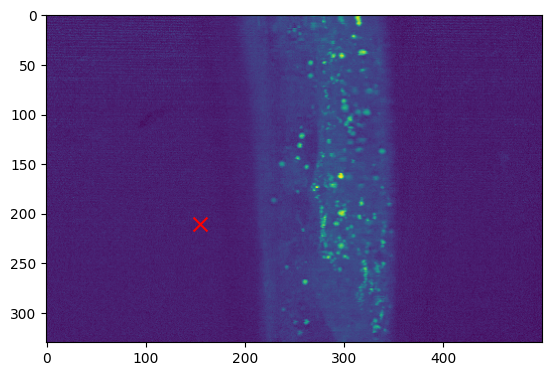

In [8]:
# Visualize the data
plt.imshow(np.imag(raw_data[:,:,750]))
plt.scatter(pixx, pixy, color='red', s=100, marker='x') 
plt.show()

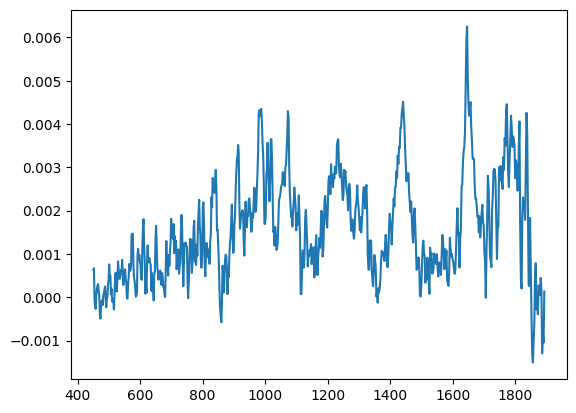

In [ ]:
# crop your data to the fingerprint region, visualize and adjust as needed
wn_mask = (wn >= 400) & (wn <= 3400)
wn_selected = wn[wn_mask]
indices = np.where(wn_mask)[0]
data = raw_data[:, :, indices]
plt.plot(wavenumbers,np.imag(data[pixx, pixy,:]))  # Choose a pixel with good intensity to plot

# Fitting Parameters and Pre-computes

In [10]:
# These parameters probably won't need to be updated

spectrum = np.imag(data[pixx, pixy, :])

x = wavenumbers.copy()
x = x.astype(np.float32)

dx = (x[-1] - x[0]) / (len(x) - 1)  # cm⁻¹ per pixel
widths = np.linspace(1, 10, 100) * dx  # or just set directly in cm⁻¹

sigmas = torch.as_tensor(widths, dtype=torch.float32)
gammas = torch.tensor([1.0], dtype=torch.float32)
x_gpu  = torch.as_tensor(x, dtype=torch.float32)

x_c  = x_gpu - x_gpu.mean()

sigs = sigmas.view(-1, 1, 1)
gams = gammas.view( 1,-1, 1)
x_bc = x_c.view(   1, 1,-1)

profiles = pseudo_voigt(x_bc, sigs, gams)
max_vals = profiles.amax(dim=-1, keepdim=True)
wavelet_peaks_cached = profiles / (max_vals + 1e-12) 
wavelet_peaks_cached = wavelet_peaks_cached.to(device)

# ── Precomputed constants (shared across all sweep calls) ─────────────────────
_x_dev     = x_gpu.to(device)
_lor4_bank = precompute_lorentz4_wavelets(sigmas.to(device), _x_dev)  # (n_widths, n_pts)

_sigma_t = torch.tensor(3.0,  dtype=torch.float32, device=device)
_gamma_t = torch.tensor(1e-6, dtype=torch.float32, device=device)
_kernel  = compute_wavelet_peak(_sigma_t, _gamma_t, _x_dev)
_kernel  = _kernel / _kernel.sum()
_ker_fft = torch.fft.fft(torch.fft.ifftshift(_kernel))  # (n_pts,)

# Param bounds tensors (reused each step)
_LO = torch.tensor([0.0,    0.0, 0.05, 0.05], device=device)
_HI = torch.tensor([1.0, 4000.0, 50.0, 50.0], device=device)

print(f"Wavelet bank : {_lor4_bank.shape}  on {_lor4_bank.device}")
print(f"Denoise kern : {_ker_fft.shape}    on {_ker_fft.device}")



Wavelet bank : torch.Size([100, 700])  on cuda:0
Denoise kern : torch.Size([700])    on cuda:0


# Quick Convolution Denoise

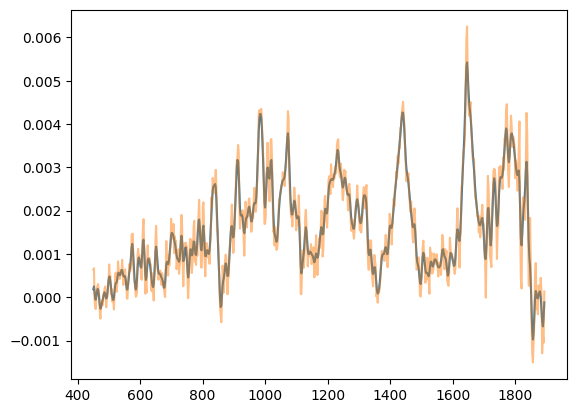

In [19]:
spectrum_denoised = denoise_spectrum(
    torch.as_tensor(spectrum, dtype=torch.float32),
    x_gpu,
    sigma=3.0,   # wavenumber units — start at ~half your narrowest peak width
    gamma=0.0,   # pure Gaussian → minimal ringing
)
plt.plot(x, spectrum_denoised.numpy(), label='Denoised Spectrum')
plt.plot(x, spectrum, alpha=0.5, label='Original Spectrum')


# Run the Fitting for one Pixel

In [20]:
#Modify the parameters as needed:

adj = 0.0002 # if the spectrum goes below zero, add a small constant to the denoised spectrum to ensure positivity and good fits
response_threshold=0.0001 # CWT response threshold: adjust up for more selective peak detection, down for more peaks (but more false positives)
amp_threshold = 1e-6 # minimum amplitude threshold for detected peaks: adjust up to filter out small peaks, down to include more (but more false positives)
min_scale_votes=3 # minimum number of wavelet scales that must vote for a peak to be included in the initial fit (adjust up for more selectivity, down for more peaks but more false positives)
min_spacing=5.0 # minimum spacing between detected peaks in wavenumber units: Should be the instrument resolution... adjust up to prevent closely spaced peaks (but may miss real peaks that are close together), adjust down to allow more closely spaced peaks (but may result in multiple peaks fitting the same feature)  
max_iter=4000  # maximum number of iterations for the fitting optimization: adjust up if fits aren't converging, down to save time (but may result in some fits not fully converging)
tol=1e-5 # convergence tolerance for the fitting optimization: adjust down for more precise fits (but may take longer to converge), adjust up to allow faster fits (but may be less precise)
scale_preference_fraction=0.9 # Scale preference fraction: between 0 and 1, this prevents the broadest wavlet response from dominanting the initial guesses - adjust down for narrow peaks, up for broad peaks

params_cd, converged_cd, n_iter_cd, response_tensor_cd, peak_mask_cd, p0_cd = process_conv_deriv_fit(spectrum_denoised + adj,x,sigmas=sigmas,gammas=gammas,wavelet_peaks=wavelet_peaks_cached,response_threshold=response_threshold, amp_threshold = amp_threshold, min_scale_votes= min_scale_votes, min_spacing= min_spacing, max_iter=max_iter,  tol=tol, scale_preference_fraction=scale_preference_fraction, )

print(f"converged: {converged_cd}  n_iter: {n_iter_cd}")
print(f"peaks detected (mask): {peak_mask_cd.sum().item()}")
print(f"non-zero fitted peaks: {(params_cd.reshape(-1,4)[:,0] > 1e-3).sum().item()}")


TypeError: process_conv_deriv_fit() got an unexpected keyword argument 'min_spacing'

In [14]:
# Visualize the fit results - adjust the parameters above as needed to get good fits to the data
plot_voigt_fit_res(x, spectrum_denoised+ adj, params_cd, title="Conv-Deriv Fit Results")

NameError: name 'spectrum_denoised' is not defined

In [15]:
# Intial conditions plot - use to determine which parameters need adjusting
plot_voigt_fit_res(x, spectrum_denoised+ adj, p0_cd, title="CWT Fitting Results")

NameError: name 'spectrum_denoised' is not defined

# Run the Fitting for a batch

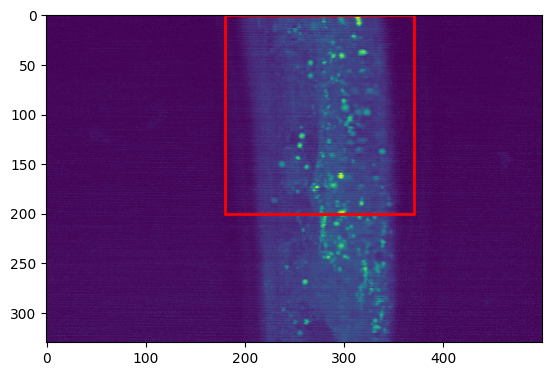

In [16]:
# Select a region from your already-loaded cube
X0, X1 = 180, 370
Y0, Y1 = 0, 200

fig,ax=plt.subplots()
ax.imshow(np.imag(data[:,:, 400]))
rect = patches.Rectangle((X0, Y0), X1-X0, Y1-Y0, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.show()

In [21]:
# ── Batch fit directly on loaded BCARS cube (no RamanDataset) ───────────────────

# Make sure sweep context exists for tidytorch_utils internals
ttu.init_sweep_context(x_gpu, sigmas, gammas, device, widths)
init_plot_context(x, widths)

# Build (B, n_pts) batch from existing data variable
cube_roi = np.asarray(data[X0:X1, Y0:Y1, :])
if np.iscomplexobj(cube_roi):
    cube_roi = np.imag(cube_roi)
spectra_np = cube_roi.reshape(-1, cube_roi.shape[-1]).astype(np.float32)
B = spectra_np.shape[0]
print(f"ROI shape: {cube_roi.shape}  ->  batch spectra: {B} × {spectra_np.shape[1]}")

spectra_gpu = torch.as_tensor(spectra_np, dtype=torch.float32, device=ttu._ctx_device)

# ── Fit controls ────────────────────────────────────────────────────────────── Adjust if the batches are too bulky 
MAX_ITER_BATCH = max_iter
TOL_BATCH = tol
AMP_THR_BATCH = amp_threshold
MIN_SPACING_BATCH = min_spacing
RESPONSE_THRESHOLD = response_threshold
MIN_SCALE_VOTES = min_scale_votes

TRANSFORM_CHUNK = 250
FIT_CHUNK = 2000

# Progress checkpoint cadences
CHECKPOINT_EVERY = 1000
FIT_CHECKPOINT_EVERY = 250

# Aggressive-start controls
AGGR_STEPS = 80
AGGR_LR_MULT = 4.0
AGGR_CLIP = 3.0
AGGR_BETA1 = 0.85

#max peaks
MAX_PEAKS_BATCH = 200

def _sync_dev(dev):
    if dev.type == "cuda":
        torch.cuda.synchronize()
    elif dev.type == "mps":
        torch.mps.synchronize()

# Warmup
with torch.no_grad():
    _ = ttu._denoise_batch(spectra_gpu[:1])

_sync_dev(ttu._ctx_device)
t0 = time.perf_counter()

# 1) Denoise + transform + vote
spec_d = ttu._denoise_batch(spectra_gpu)
resp = ttu._lor4_transform_batch(spec_d)
_, n_widths, n_pts = resp.shape

flat_masks = ttu.find_peaks_derivative_mask_batch(
    ttu._x_dev, resp.reshape(B * n_widths, n_pts), min_height=0.0
)
masks = flat_masks.reshape(B, n_widths, n_pts)
vote_count = masks.long().sum(dim=1)
max_resp = resp.max(dim=1).values
peak_masks = (vote_count >= MIN_SCALE_VOTES) & (max_resp > RESPONSE_THRESHOLD)

# 2) Build padded p0 + gradient mask
npq_max = MAX_PEAKS_BATCH * 4
p0_flat_list = []
n_real_peaks = []

t_init0 = time.perf_counter()
for i in range(B):
    p0 = ttu.build_initial_guesses_from_derivative_mask(
        resp[i].unsqueeze(1),
        ttu._ctx_sigmas.to(ttu._ctx_device),
        ttu._ctx_gammas[:1].to(ttu._ctx_device),
        ttu._x_dev,
        spec_d[i],
        peak_masks[i],
        max_peaks=MAX_PEAKS_BATCH,
        min_spacing=MIN_SPACING_BATCH,
        scale_preference_fraction=0.008,
    )
    p0_flat = p0[:npq_max]
    p0_flat_list.append(p0_flat)
    n_peaks_i = int((p0_flat[0::4] > 0).sum().item())
    n_real_peaks.append(min(n_peaks_i, MAX_PEAKS_BATCH))

    done = i + 1
    if (done % CHECKPOINT_EVERY == 0) or (done == B):
        elapsed = time.perf_counter() - t_init0
        px_per_sec = done / max(elapsed, 1e-9)
        eta = (B - done) / max(px_per_sec, 1e-9)
        print(f"[checkpoint] initialized {done}/{B} spectra\n")
        print(f"({100.0 * done / B:.1f}%) | elapsed {elapsed:.1f}s | ETA {eta:.1f}s\n"
        )

max_real = max(1, max(n_real_peaks) if n_real_peaks else 1)
npq = max_real * 4
p0_batch = torch.zeros(B, npq, device=ttu._ctx_device)
grad_mask = torch.zeros(B, npq, dtype=torch.float32, device=ttu._ctx_device)

for i, (p0_flat, n_peaks_i) in enumerate(zip(p0_flat_list, n_real_peaks)):
    n_take = min(p0_flat.numel(), npq)
    p0_batch[i, :n_take] = p0_flat[:n_take]
    grad_mask[i, :n_peaks_i * 4] = 1.0

# 3) Batched Adam fit
_sync_dev(ttu._ctx_device)
t_fit0 = time.perf_counter()
params_batch = ttu._fit_batch_adam(
    spec_d, ttu._x_dev, p0_batch, grad_mask,
    max_iter=MAX_ITER_BATCH,
    tol=TOL_BATCH,
    aggressive_start_steps=AGGR_STEPS,
    aggressive_lr_mult=AGGR_LR_MULT,
    aggressive_clip_norm=AGGR_CLIP,
    aggressive_beta1=AGGR_BETA1,
    progress_every=FIT_CHECKPOINT_EVERY,
    progress_prefix="fit",
)
_sync_dev(ttu._ctx_device)
fit_only_sec = time.perf_counter() - t_fit0

# 4) Post-process fitted peaks
params_batch = ttu._prune_peaks_batch(params_batch, amp_threshold=AMP_THR_BATCH)
params_batch = ttu._deduplicate_peaks_batch(params_batch, MIN_SPACING_BATCH)

# Reconstruct model for first ROI spectrum
model0 = ttu._compute_model_batch(params_batch[:1], ttu._x_dev).squeeze(0).detach().cpu().numpy()
spec0 = spectra_np[0]
plt.figure(figsize=(9,4))
plt.plot(x, spec0, label='Input spectrum (ROI[0])', alpha=0.7)
plt.plot(x, model0, label='Batched fitted model', lw=2)
plt.title('BCARS batch fit example (first spectrum)')
plt.legend()
plt.tight_layout()
plt.show()

Sweep context initialised on cuda
  Wavelet bank : torch.Size([100, 700])
  Denoise kern : torch.Size([700])
ROI shape: (150, 200, 700)  ->  batch spectra: 30000 × 700


OutOfMemoryError: CUDA out of memory. Tried to allocate 15.65 GiB. GPU 0 has a total capacity of 23.46 GiB of which 7.30 GiB is free. Including non-PyTorch memory, this process has 16.16 GiB memory in use. Of the allocated memory 722.88 MiB is allocated by PyTorch, and 15.26 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
filename = "lipid_droplet_fitted_20260326"
save_h5_file(
    filename,
    SAVE_FOLDER="/YOUR/DESTINATION/PATH/HERE",
    attrs=attrs,
    data=raw_data,
    nrb=nrb,
    dark=dark,
    model=model0,  # You can save the full batch if desired, but here we save just the first spectrum's model for demonstration
    peak_params=params_batch.cpu().numpy(),
    x_axis=x.astype(np.float32),
)

In [ ]:
# ── Reshape batched params back to ROI-aligned cube and save ─────────────────────
params_np = params_batch.detach().cpu().numpy().astype(np.float32)   # (B, n_params)
roi_h = int(X1 - X0)
roi_w = int(Y1 - Y0)

if params_np.shape[0] != roi_h * roi_w:
    raise ValueError(
        f"Batch size mismatch: got {params_np.shape[0]} spectra, expected {roi_h*roi_w} from ROI shape."
    )

peak_params_roi = params_np.reshape(roi_h, roi_w, -1)
print(f"peak_params_roi shape: {peak_params_roi.shape}  (x={roi_h}, y={roi_w}, params={peak_params_roi.shape[-1]})")

# Compute model cube in chunks — _compute_model_batch(full_batch) would OOM
MODEL_CHUNK = FIT_CHUNK  # reuse the same safe chunk size
model_chunks = []
with torch.no_grad():
    for mc_start in range(0, B, MODEL_CHUNK):
        mc_end = min(mc_start + MODEL_CHUNK, B)
        mc = ttu._compute_model_batch(
            params_batch[mc_start:mc_end], ttu._x_dev
        ).cpu().numpy().astype(np.float32)
        model_chunks.append(mc)
model_batch_np = np.concatenate(model_chunks, axis=0)
model_roi = model_batch_np.reshape(roi_h, roi_w, -1)
print(f"model_roi shape: {model_roi.shape}")

save_h5_file(
    "replaced_myo3_p0lyme_roi_batch_fit",
    SAVE_FOLDER="/home/adiering3/projects/Raman-Spectral-Analysis",
    attrs=attrs,
    data=raw_data,
    nrb=nrb,
    dark=dark,
    model=model_roi,  # Save the full model cube for the ROI
    peak_params=peak_params_roi,  # Save the peak parameters cube for the ROI
    x_axis=x.astype(np.float32),
)

print("Saved -> bcars_roi_batch_fit.npz")

amp0_map = peak_params_roi[:, :, 0]
plt.figure(figsize=(5,4))
plt.imshow(amp0_map, origin='lower', cmap='viridis')
plt.colorbar(label='Amplitude (peak 0)')
plt.title('ROI map: fitted first-peak amplitude')
plt.tight_layout()
plt.show()

In [ ]:
# Visualize and Compare the original data and the fitted model for a specific spectral index (channel) across the ROI.

SPEC_IDX = 300  # spectral index to display — change to any channel of interest

orig_slice  = np.imag(data[X0:X1, Y0:Y1, SPEC_IDX])
model_slice = model_roi[:, :, SPEC_IDX]

vmin = orig_slice.min()
vmax = orig_slice.max()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(orig_slice,  origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
axes[0].set_title(f'Original data  (channel {SPEC_IDX})')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(model_slice, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax, aspect='auto')
axes[1].set_title(f'Fitted model   (channel {SPEC_IDX})')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()